# Heatbudget AREA1 2021

## Module 导入

In [10]:
import os
import numpy as np
import scipy as sp
import pandas as pd
from datetime import date
import marineHeatWaves as mhw
import netCDF4 as nc
import datetime
import matplotlib.pyplot as plt
from tqdm import notebook
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, Executor
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.backends.backend_agg import FigureCanvasAgg
import PIL.Image as Image
from scipy.stats import pearsonr
time=pd.date_range('2021-7-1','2021-9-30')

## $Q$ 表面净热通量总和


### Functions

$$
Q=\frac{Q_{net}-Q_{z}}{\rho_{0}C_{p}h}
$$
- $Q_{net}=Q_{ShortwaveRadiation}+Q_{LongwaveRadiation}+Q_{LatentHeatFlux}+Q_{SensibleHeatFlux}$
- $Q_{z}=Q_{ShortwaveRadiation}(0.58e^{\frac{h}{0.35}}+0.42e^\frac{h}{23})$
- $\rho _{0}: 1.024 g/cm^{3}$
- $C_{p}: 3850 J\cdot kg^{-1} \cdot C^{-1}$
- *h*为*MLD*，*混合层深度* 与**海表温差2℃**


### Data list

- *h*(MLD)
  - [depth](/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy)
  - [thetao2021](/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy)
- $Q_{ShortwaveRadiation}$ 
  - [ssrs](/lustre/home/yuhanxue/data/ERA/0.25area/re/new/ssrs.npy)
- $Q_{LongwaveRadiation}$ 
  - [strs](/lustre/home/yuhanxue/data/ERA/0.25area/re/new/strs.npy)
- $Q_{LatentHeatFlux}$ 
  - [slhf](/lustre/home/yuhanxue/data/ERA/0.25area/re/new/sshfs.npy)
- $Q_{SensibleHeatFlux}$ 
  - [sshf](lustre/home/yuhanxue/data/ERA/0.25area/re/new/sshfs.npy)

### 计算MLD

In [11]:
depth=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy')
def mld(dat):
    global depth
    if dat[0]-0.8>dat[-1]:
        return depth[dat[0]-0.8-dat>0][0]
    else:
        return np.nan
def list_map(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(mld,dat)))
    del pool
    return ans
def onetime(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map,a)))
    del pool
    return ans
thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")
pool = ProcessPoolExecutor(max_workers=3)
mld2021a1=np.array(list(pool.map(onetime,thetaos2020a1)))
del pool

### 读取$Q_{ShortwaveRadiation}$、$Q_{LongwaveRadiation}$、$Q_{LatentHeatFlux}$、$Q_{SensibleHeatFlux}$ 

In [12]:
times=pd.to_datetime(np.load("/lustre/home/yuhanxue/data/ERA/0.25area/re/timess.npy",allow_pickle=True))
time2021ind=(times.year==2021)&((times.month==7)|(times.month==8)|(times.month==9))
ssrs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/ssrs.npy')[time2021ind]/3600#ShortwaveRadiation
strs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/strs.npy')[time2021ind]/3600#LongwaveRadiation
slhfs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/slhfs.npy')[time2021ind]/3600#LatentHeatFlux
sshfs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/sshfs.npy')[time2021ind]/3600#SensibleHeatFlux
del times,time2021ind

### 计算公式
- $Q_{net}=Q_{ShortwaveRadiation}+Q_{LongwaveRadiation}+Q_{LatentHeatFlux}+Q_{SensibleHeatFlux}$
- $Q_{z}=Q_{ShortwaveRadiation}(0.58e^{-\frac{h}{0.35}}+0.42e^{-\frac{h}{23}})$
- $Q=\frac{Q_{net}-Q_{z}}{\rho_{0}C_{p}h}$

In [13]:
Q_net=ssrs_2021+strs_2021+slhfs_2021+sshfs_2021
Q_z=ssrs_2021*(0.58*np.exp(-1*mld2021a1/0.35)+0.42*np.exp(-1*mld2021a1/23))
Q=(Q_net-Q_z)/(1.024*1e3*3850*mld2021a1)*24*3600

## Mixed Layer Temperature Tendency

### Functions
$$
Mixed Layer Temperature Tendency=\frac{\mathrm{d}\mathrm{T_{m}}}{\mathrm{d}\mathrm{t}}
$$
- $\mathrm{T_{m}}$为$\mathrm{T_{0}}$至$\mathrm{T_{-h}}$的平均值

### Data list

- *h*(MLD)

### 计算tm&mltt

In [14]:
# T_m
depth=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy')
def tm(dat):
    global depth
    if dat[0]-0.8>dat[-1]:
        return np.nanmean(dat[dat[0]-0.8-dat<0])
    else:
        return np.nan
def list_map2(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(tm,dat)))
    del pool
    return ans
def onetime2(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map2,a)))
    del pool
    return ans
# thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")
pool = ProcessPoolExecutor(max_workers=3)
tms=np.array(list(pool.map(onetime2,thetaos2020a1)))
del pool
mltt=tms[1:,:,:]-tms[:-1,:,:]
#np.save('12_10mltt.npy',mltt)

## HADV 水平平流项

### Functions
$$
HADV=-\overrightarrow{U_{m}}\bigtriangledown T_{m}=-(u_{m}\frac{\mathrm{d}T_{m}}{\mathrm{d}x}+v_{m}\frac{\mathrm{d}T_{m}}{\mathrm{d}y})
$$
- $ \overrightarrow{U_{m}} $为0~h平均水平速度
- $T_{m}$为0~-h深度的平均位温
- $u_{m}$为水平经向速度
- $v_{m}$为水平纬向速度
- 注：纬度长度不固定，需要进行修正，修正公式:$111(Δ lon)\cdot cos(lat)$

### Data list
- uos
- vos
- tm
- lon_4
- lat_4

### 数据导入

In [15]:
us2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/uos_2021.npy")*3600*24
vs2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/vo_2021.npy")*3600*24
lat_4=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/lats.npy')
lon_4=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/lons.npy')
lat_4_ind=(lat_4>=35)&(lat_4<=50)
lon_4_ind=(lon_4>=195)&(lon_4<=230)
lat_4=lat_4[lat_4_ind]
lon_4=lon_4[lon_4_ind]
print(f'lat_4 range:{lat_4[0]:.2f}~{lat_4[-1]:.2f} | freq:{abs(lat_4[1]-lat_4[0])}\nlon_4 range:{lon_4[0]:.2f}~{lon_4[-1]:.2f} | freq:{lon_4[1]-lon_4[0]}')

lat_4 range:50.00~35.00 | freq:0.25
lon_4 range:195.00~230.00 | freq:0.25


### 计算$u_{m}$、$v_{m}$、经向&纬向积分、HADV

In [16]:
depth=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy')
def tm(dat):
    global depth
    if dat[1,0]-0.8>dat[1,-1]:
        return np.nanmean(dat[0,dat[1,0]-0.8-dat[1,:]<0])
    else:
        return np.nan
def list_map2(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(tm,dat)))
    del pool
    return ans
def onetime2(dat):
    #a=np.swapaxes(dat,0,1)
    #a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map2,dat)))
    del pool
    #ans=np.array(list(map(list_map2,dat)))
    return ans

def ms(dat):
    global thetaos2020a1
    pool = ProcessPoolExecutor(max_workers=3)
    a=np.swapaxes(np.swapaxes(np.swapaxes(np.swapaxes(np.swapaxes(np.array([dat,thetaos2020a1]),0,1),2,3),1,2),3,4),2,3)
    ans=np.array(list(pool.map(onetime2,a)))
    del pool
    return ans
um=ms(us2020a1)
vm=ms(vs2020a1)

dx=np.array([(tms[:,i,1:]-tms[:,i,:-1])/(111e3/4*np.cos(lat_4[i]/180*np.pi)) for i in range(0,61)])
dx=np.swapaxes(dx,0,1)
dy=(tms[:,1:,:]-tms[:,:-1,:])/(111e3/4)

hadv=(um[:,:-1,:-1]*dx[:,:-1,:]+um[:,:-1,:-1]*dy[:,:,:-1])*-1

In [17]:
um[50,20,40]

-2098.187258094549

In [18]:
111e3/4*np.cos(lat_4[:]/180*np.pi)

array([17837.355, 17929.94 , 18022.182, 18114.084, 18205.637, 18296.844,
       18387.707, 18478.215, 18568.371, 18658.178, 18747.627, 18836.72 ,
       18925.453, 19013.828, 19101.838, 19189.486, 19276.77 , 19363.686,
       19450.232, 19536.408, 19622.213, 19707.645, 19792.701, 19877.379,
       19961.68 , 20045.6  , 20129.139, 20212.295, 20295.064, 20377.45 ,
       20459.445, 20541.053, 20622.268, 20703.092, 20783.521, 20863.553,
       20943.191, 21022.428, 21101.266, 21179.701, 21257.732, 21335.36 ,
       21412.582, 21489.395, 21565.8  , 21641.793, 21717.377, 21792.545,
       21867.299, 21941.635, 22015.555, 22089.055, 22162.135, 22234.793,
       22307.027, 22378.838, 22450.223, 22521.176, 22591.705, 22661.803,
       22731.469], dtype=float32)

In [19]:
vm[50,20,40]

-1666.5676686912775

In [20]:
tms[50,20,41]-tms[50,20,40]

-0.01209956226926856

## 垂直夹卷项与垂直混合项的加和(OVMIX)

### Functions
$$
OVMIX=-\frac{1}{h}(T_{m}-T_{-h})W_{E}-\frac{1}{h}k_v\frac{\mathrm{d} T}{\mathrm{d} Z}\bigg|_{z=-h}
$$
- $W_{E}=\frac{\mathrm{d}h}{\mathrm{d}t}$
  - h(MLD)随时间的变化
- $K_{v}:10^{-4} \cdot m^{2}\cdot s^{-1}$

### Data Filelist
- $h$(mld)
- $T_{m}$(tms)

### $W_{E}$

In [21]:
W_e=mld2021a1[1:,:,:]-mld2021a1[:-1,:,:]

### $T_{-h}$

In [22]:
def th(dat):
    global depth
    if dat[0]-0.8>dat[-1]:
        return dat[dat[0]-0.8-dat>0][0]
    else:
        return np.nan
def list_map3(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(th,dat)))
    del pool
    return ans
def onetime3(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map3,a)))
    del pool
    return ans
# thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")
pool = ProcessPoolExecutor(max_workers=3)
ths=np.array(list(pool.map(onetime3,thetaos2020a1)))
del pool
#mltt=tms[1:,:,:]-tms[:-1,:,:]

### $\frac{\mathrm{d} T}{\mathrm{d} Z}\bigg|_{z=-h}$

In [23]:
def dtdz(dat):
    global depth
    if dat[0]-0.8>dat[-1]:
        return (dat[dat[0]-0.8-dat>0][0]-dat[dat[0]-0.8-dat<0][-1])/(-1*(depth[dat[0]-0.8-dat>0][0])-(-1)*(depth[dat[0]-0.8-dat<0][-1]))
    else:
        return np.nan
def list_map4(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(dtdz,dat)))
    del pool
    return ans
def onetime4(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map4,a)))
    del pool
    return ans
# thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")
pool = ProcessPoolExecutor(max_workers=3)
dtdz=np.array(list(pool.map(onetime4,thetaos2020a1)))
del pool

### OVMIX
$$
OVMIX=-\frac{1}{h}(T_{m}-T_{-h})W_{E}-\frac{1}{h}k_v\frac{\mathrm{d} T}{\mathrm{d} Z}\bigg|_{z=-h}
$$

In [24]:
ovmix1=(-1/mld2021a1*(tms-ths))
ovmix1=ovmix1[:-1,:,:]*W_e
ovmix2=-1/mld2021a1*(1e-4)*24*3600*dtdz
ovmix=ovmix1+ovmix2[:-1,:,:]

In [25]:
ovmix1[:-1,:,:].shape

(90, 61, 141)

## Draw

### HADV Q

In [26]:
np.min(Q)

-0.4800220974191506

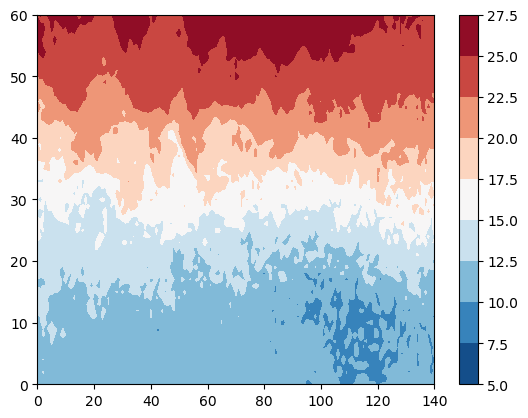

In [27]:
c=plt.contourf(ths[70,:,:],cmap='RdBu_r')
plt.colorbar(c)

Text(0.5, 1.0, 'OVMIX')

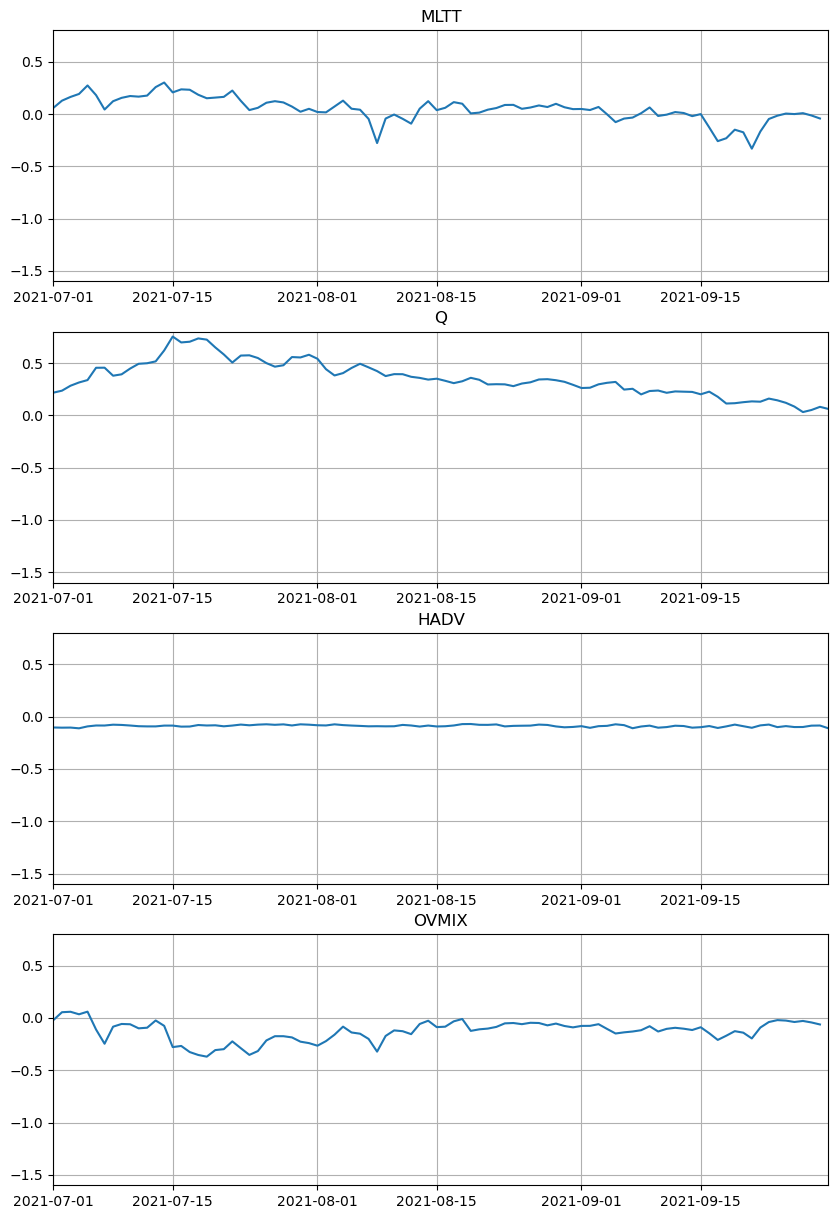

In [28]:
plt.figure(figsize=[10,15])
plt.subplot(4,1,1)
plt.plot(time[:-1],np.mean(np.mean(mltt,axis=1),axis=1))
plt.ylim(-1.6,0.8)
plt.xlim(time[0],time[-1])
plt.grid()
plt.title('MLTT')
plt.subplot(4,1,2)
plt.plot(time,np.mean(np.mean(Q,axis=1),axis=1))
plt.ylim(-1.6,0.8)
plt.xlim(time[0],time[-1])
plt.grid()
plt.title('Q')
plt.subplot(4,1,3)
plt.plot(time,np.mean(np.mean(hadv,axis=1),axis=1))
plt.ylim(-1.6,0.8)
plt.xlim(time[0],time[-1])
plt.grid()
plt.title('HADV')
plt.subplot(4,1,4)
plt.plot(time[:-1],np.mean(np.mean(ovmix,axis=1),axis=1))
plt.ylim(-1.6,0.8)
plt.xlim(time[0],time[-1])
plt.grid()
plt.title('OVMIX')


In [29]:
def lb(dat):
    dat

In [30]:
np.savez('12_20_heatbudget.npz',Q=Q,ovmix=ovmix,hadv=hadv,mltt=mltt,time=time,Q_net=Q_net,Q_z=Q_z)

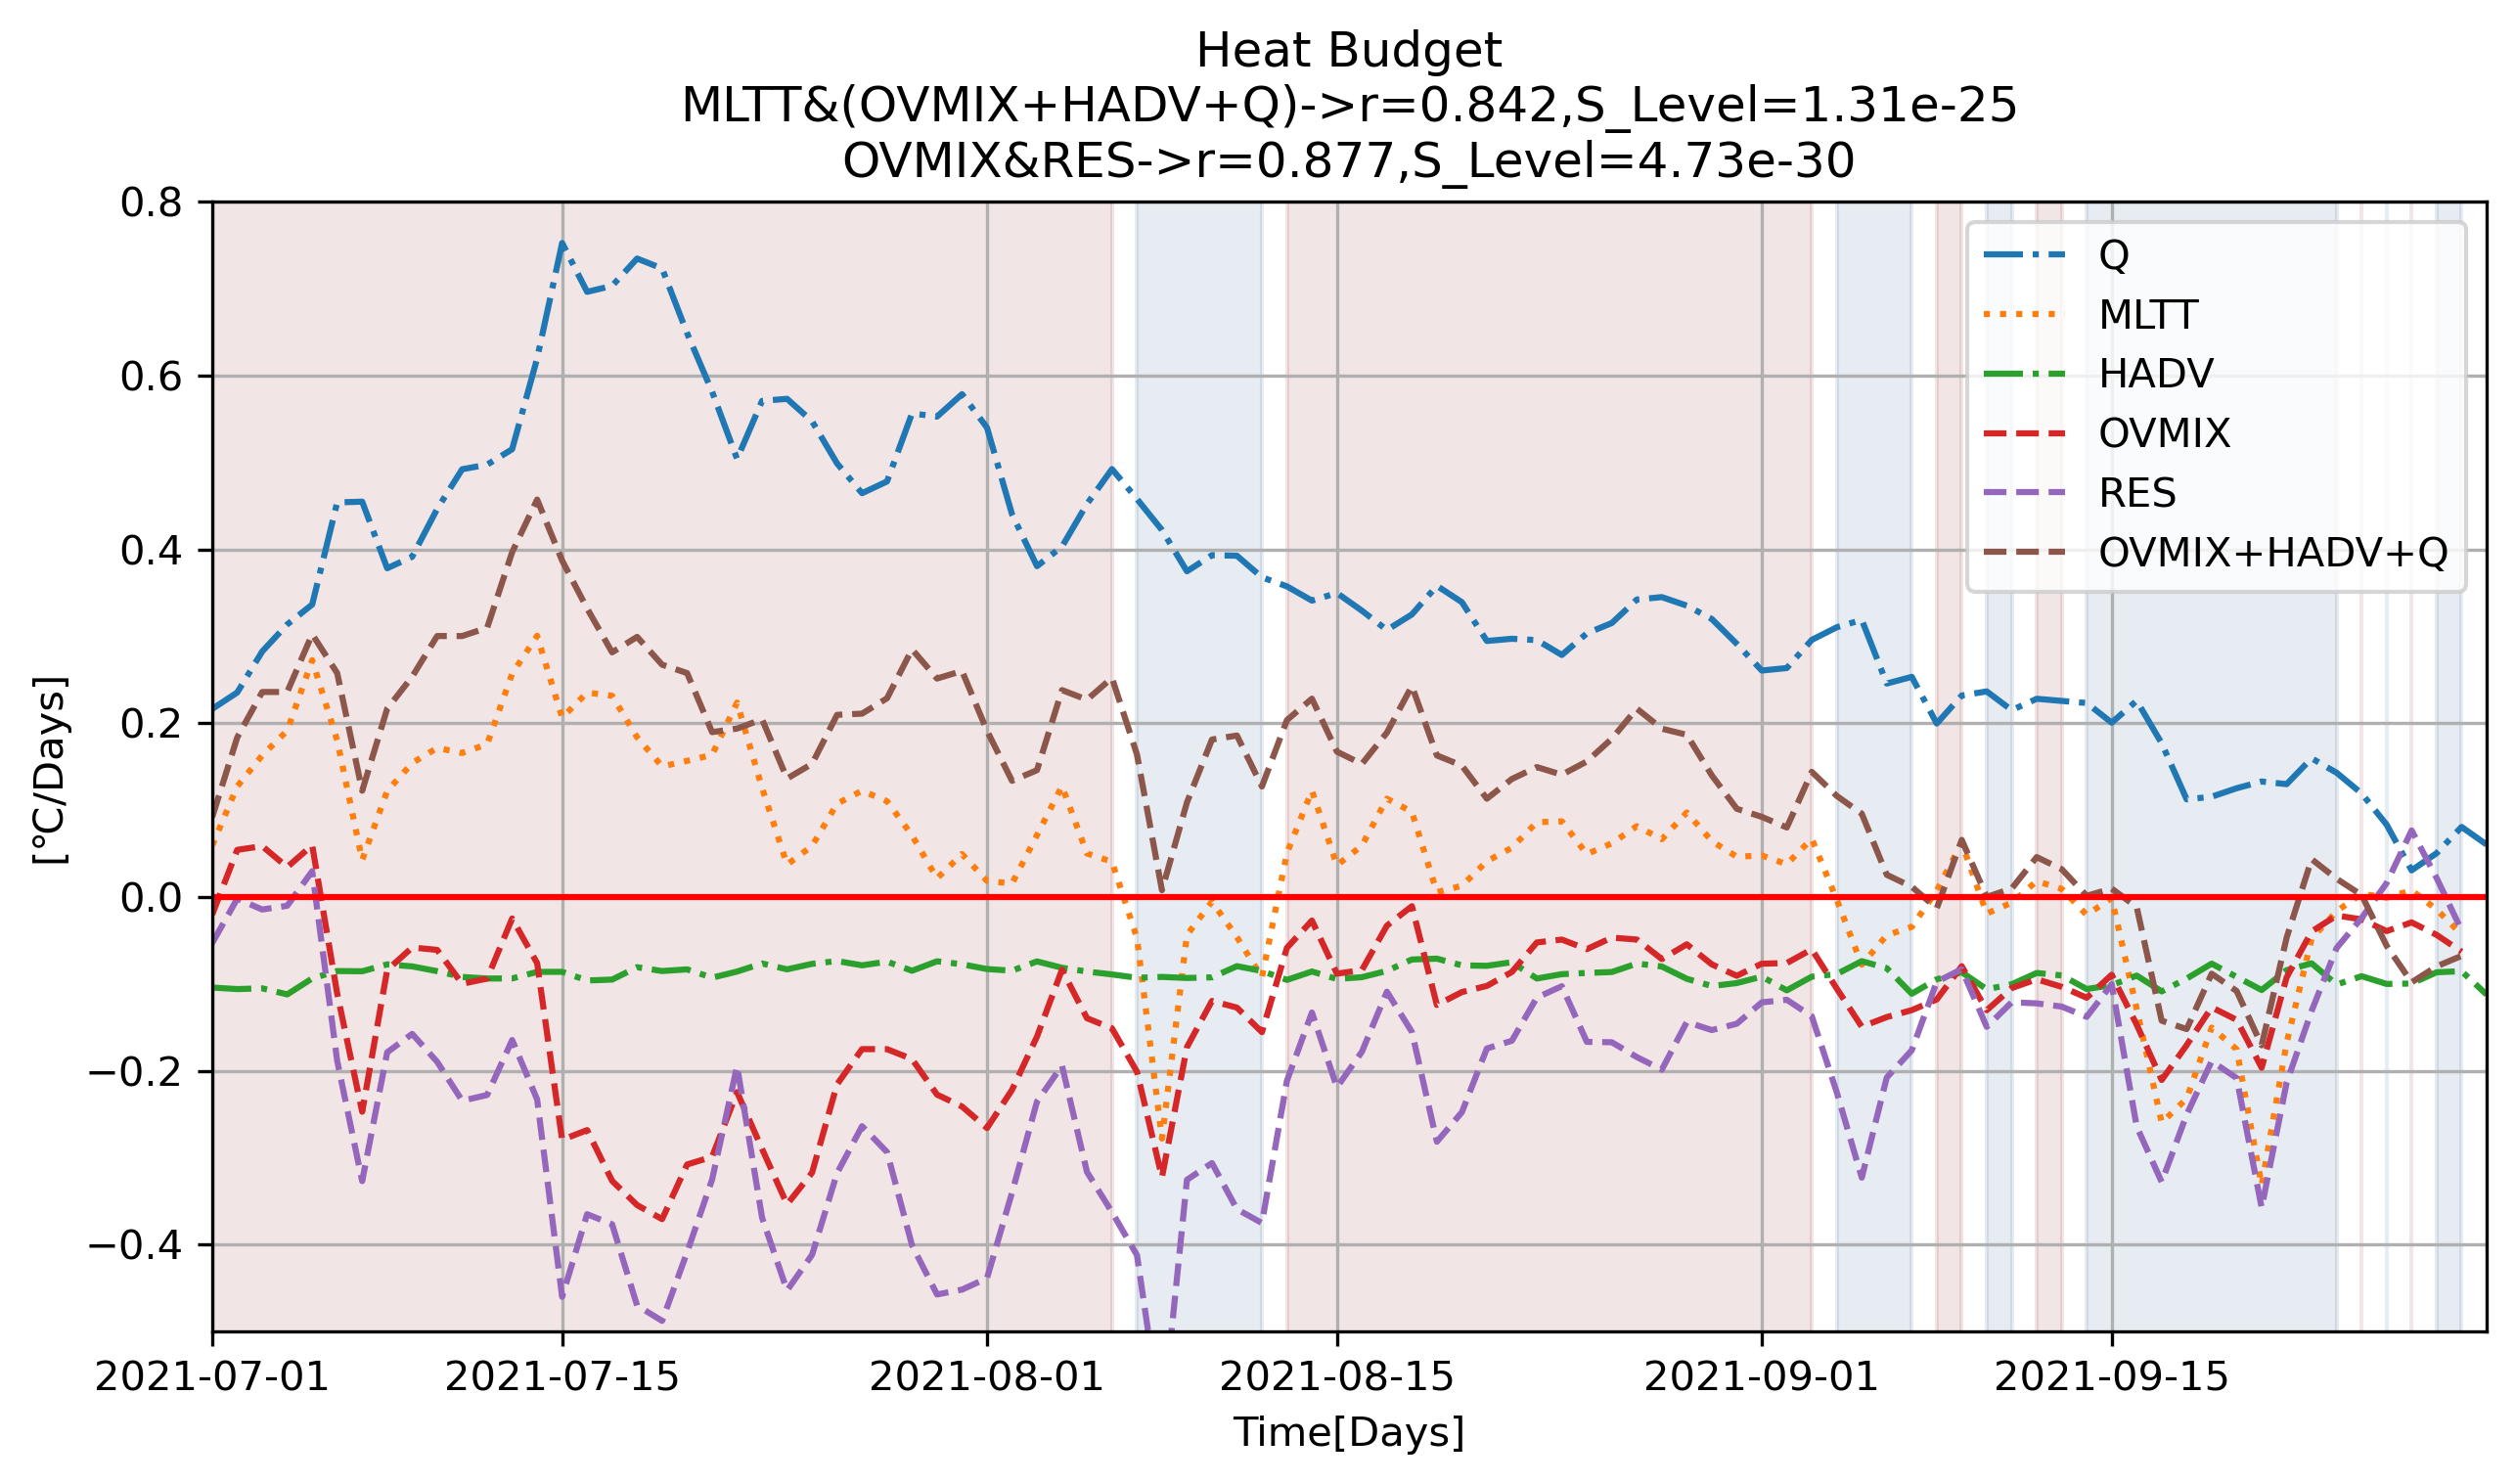

In [31]:
plt.figure(figsize=[10,5],dpi=300)
pc1 = pearsonr(np.mean(np.mean(Q,axis=1),axis=1)[:-1]+np.mean(np.mean(ovmix,axis=1),axis=1)+np.mean(np.mean(hadv,axis=1),axis=1)[:-1], np.mean(np.mean(mltt,axis=1),axis=1))
pc2 = pearsonr(np.mean(np.mean(ovmix,axis=1),axis=1), np.mean(np.mean(mltt,axis=1),axis=1)-np.mean(np.mean(Q,axis=1),axis=1)[:-1]-np.mean(np.mean(hadv,axis=1),axis=1)[:-1])
y0=np.zeros(shape=[time.shape[0]])
y1=np.copy(y0)
y1[:]=1000
y0[:]=-1000
plt.title('Heat Budget'+f'\nMLTT&(OVMIX+HADV+Q)->r={pc1[0]:.3f},S_Level={pc1[1]:.2e}'+f'\nOVMIX&RES->r={pc2[0]:.3f},S_Level={pc2[1]:.2e}')
plt.plot(time,np.mean(np.mean(Q,axis=1),axis=1),linestyle='-.',label='Q')
plt.plot(time[:-1],np.mean(np.mean(mltt,axis=1),axis=1),linestyle=':',label='MLTT')
plt.plot(time,np.mean(np.mean(hadv,axis=1),axis=1),linestyle='dashdot',label='HADV')
#pltsea of thieves Ocean.plot(time[:-1],np.mean(np.mean(ovmix1,axis=1),axis=1),label='ENT')
#plt.plot(time,np.mean(np.mean(ovmix2,axis=1),axis=1),label='MIX')
plt.plot(time[:-1],np.mean(np.mean(ovmix,axis=1),axis=1),linestyle='--',label='OVMIX')
plt.plot(time[:-1],np.mean(np.mean(mltt,axis=1),axis=1)-np.mean(np.mean(Q,axis=1),axis=1)[:-1]-np.mean(np.mean(hadv,axis=1),axis=1)[:-1],linestyle='--',label='RES')
plt.plot(time[:-1],np.mean(np.mean(Q,axis=1),axis=1)[:-1]+np.mean(np.mean(ovmix,axis=1),axis=1)+np.mean(np.mean(hadv,axis=1),axis=1)[:-1],linestyle='--',label='OVMIX+HADV+Q')
plt.legend()
plt.plot(time,np.array([0]*time.shape[0]),'r')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt,axis=1),axis=1)-0>0,alpha=0.1,color='#840000')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt,axis=1),axis=1)-0<0,alpha=0.1,color='#10457e')
plt.ylim(-0.5,0.8)
plt.xlim(time[0],time[-1])
plt.ylabel('[℃/Days]')
plt.xlabel('Time[Days]')
plt.grid()

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import pearsonr
daset=np.load('12_20_heatbudget.npz')
print(daset.files)
time=pd.date_range('2021-7-1','2021-9-30')
Q=daset["Q"]
ovmix=daset["ovmix"]
hadv=daset["hadv"]
mltt=daset["mltt"]




plt.figure(figsize=[10,5],dpi=300)
pc1 = pearsonr(np.mean(np.mean(Q,axis=1),axis=1)[:-1]+np.mean(np.mean(ovmix,axis=1),axis=1)+np.mean(np.mean(hadv,axis=1),axis=1)[:-1], np.mean(np.mean(mltt,axis=1),axis=1))
pc2 = pearsonr(np.mean(np.mean(ovmix,axis=1),axis=1), np.mean(np.mean(mltt,axis=1),axis=1)-np.mean(np.mean(Q,axis=1),axis=1)[:-1]-np.mean(np.mean(hadv,axis=1),axis=1)[:-1])
y0=np.zeros(shape=[time.shape[0]])
y1=np.copy(y0)
y1[:]=1000
y0[:]=-1000
plt.title('Heat Budget'+f'\nMLTT&(OVMIX+HADV+Q)->r={pc1[0]:.3f},S_Level={pc1[1]:.2e}'+f'\nOVMIX&RES->r={pc2[0]:.3f},S_Level={pc2[1]:.2e}')
plt.plot(time,np.mean(np.mean(Q,axis=1),axis=1),linestyle='-.',label='Q')
plt.plot(time[:-1],np.mean(np.mean(mltt,axis=1),axis=1),linestyle=':',label='MLTT')
plt.plot(time,np.mean(np.mean(hadv,axis=1),axis=1),linestyle='dashdot',label='HADV')
#plt.plot(time[:-1],np.mean(np.mean(ovmix1,axis=1),axis=1),label='ENT')
#plt.plot(time,np.mean(np.mean(ovmix2,axis=1),axis=1),label='MIX')
plt.plot(time[:-1],np.mean(np.mean(ovmix,axis=1),axis=1),linestyle='--',label='OVMIX')
plt.plot(time[:-1],np.mean(np.mean(mltt,axis=1),axis=1)-np.mean(np.mean(Q,axis=1),axis=1)[:-1]-np.mean(np.mean(hadv,axis=1),axis=1)[:-1],linestyle='--',label='RES')
plt.plot(time[:-1],np.mean(np.mean(Q,axis=1),axis=1)[:-1]+np.mean(np.mean(ovmix,axis=1),axis=1)+np.mean(np.mean(hadv,axis=1),axis=1)[:-1],linestyle='--',label='OVMIX+HADV+Q')
plt.legend()
plt.plot(time,np.array([0]*time.shape[0]),'r')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt,axis=1),axis=1)-0>0,alpha=0.1,color='#840000')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt,axis=1),axis=1)-0<0,alpha=0.1,color='#10457e')
plt.ylim(-0.5,0.8)
plt.xlim(time[0],time[-1])
plt.ylabel('[℃/Days]')
plt.xlabel('Time[Days]')
plt.grid()

FileNotFoundError: [Errno 2] No such file or directory: '12_20_heatbudget.npz'

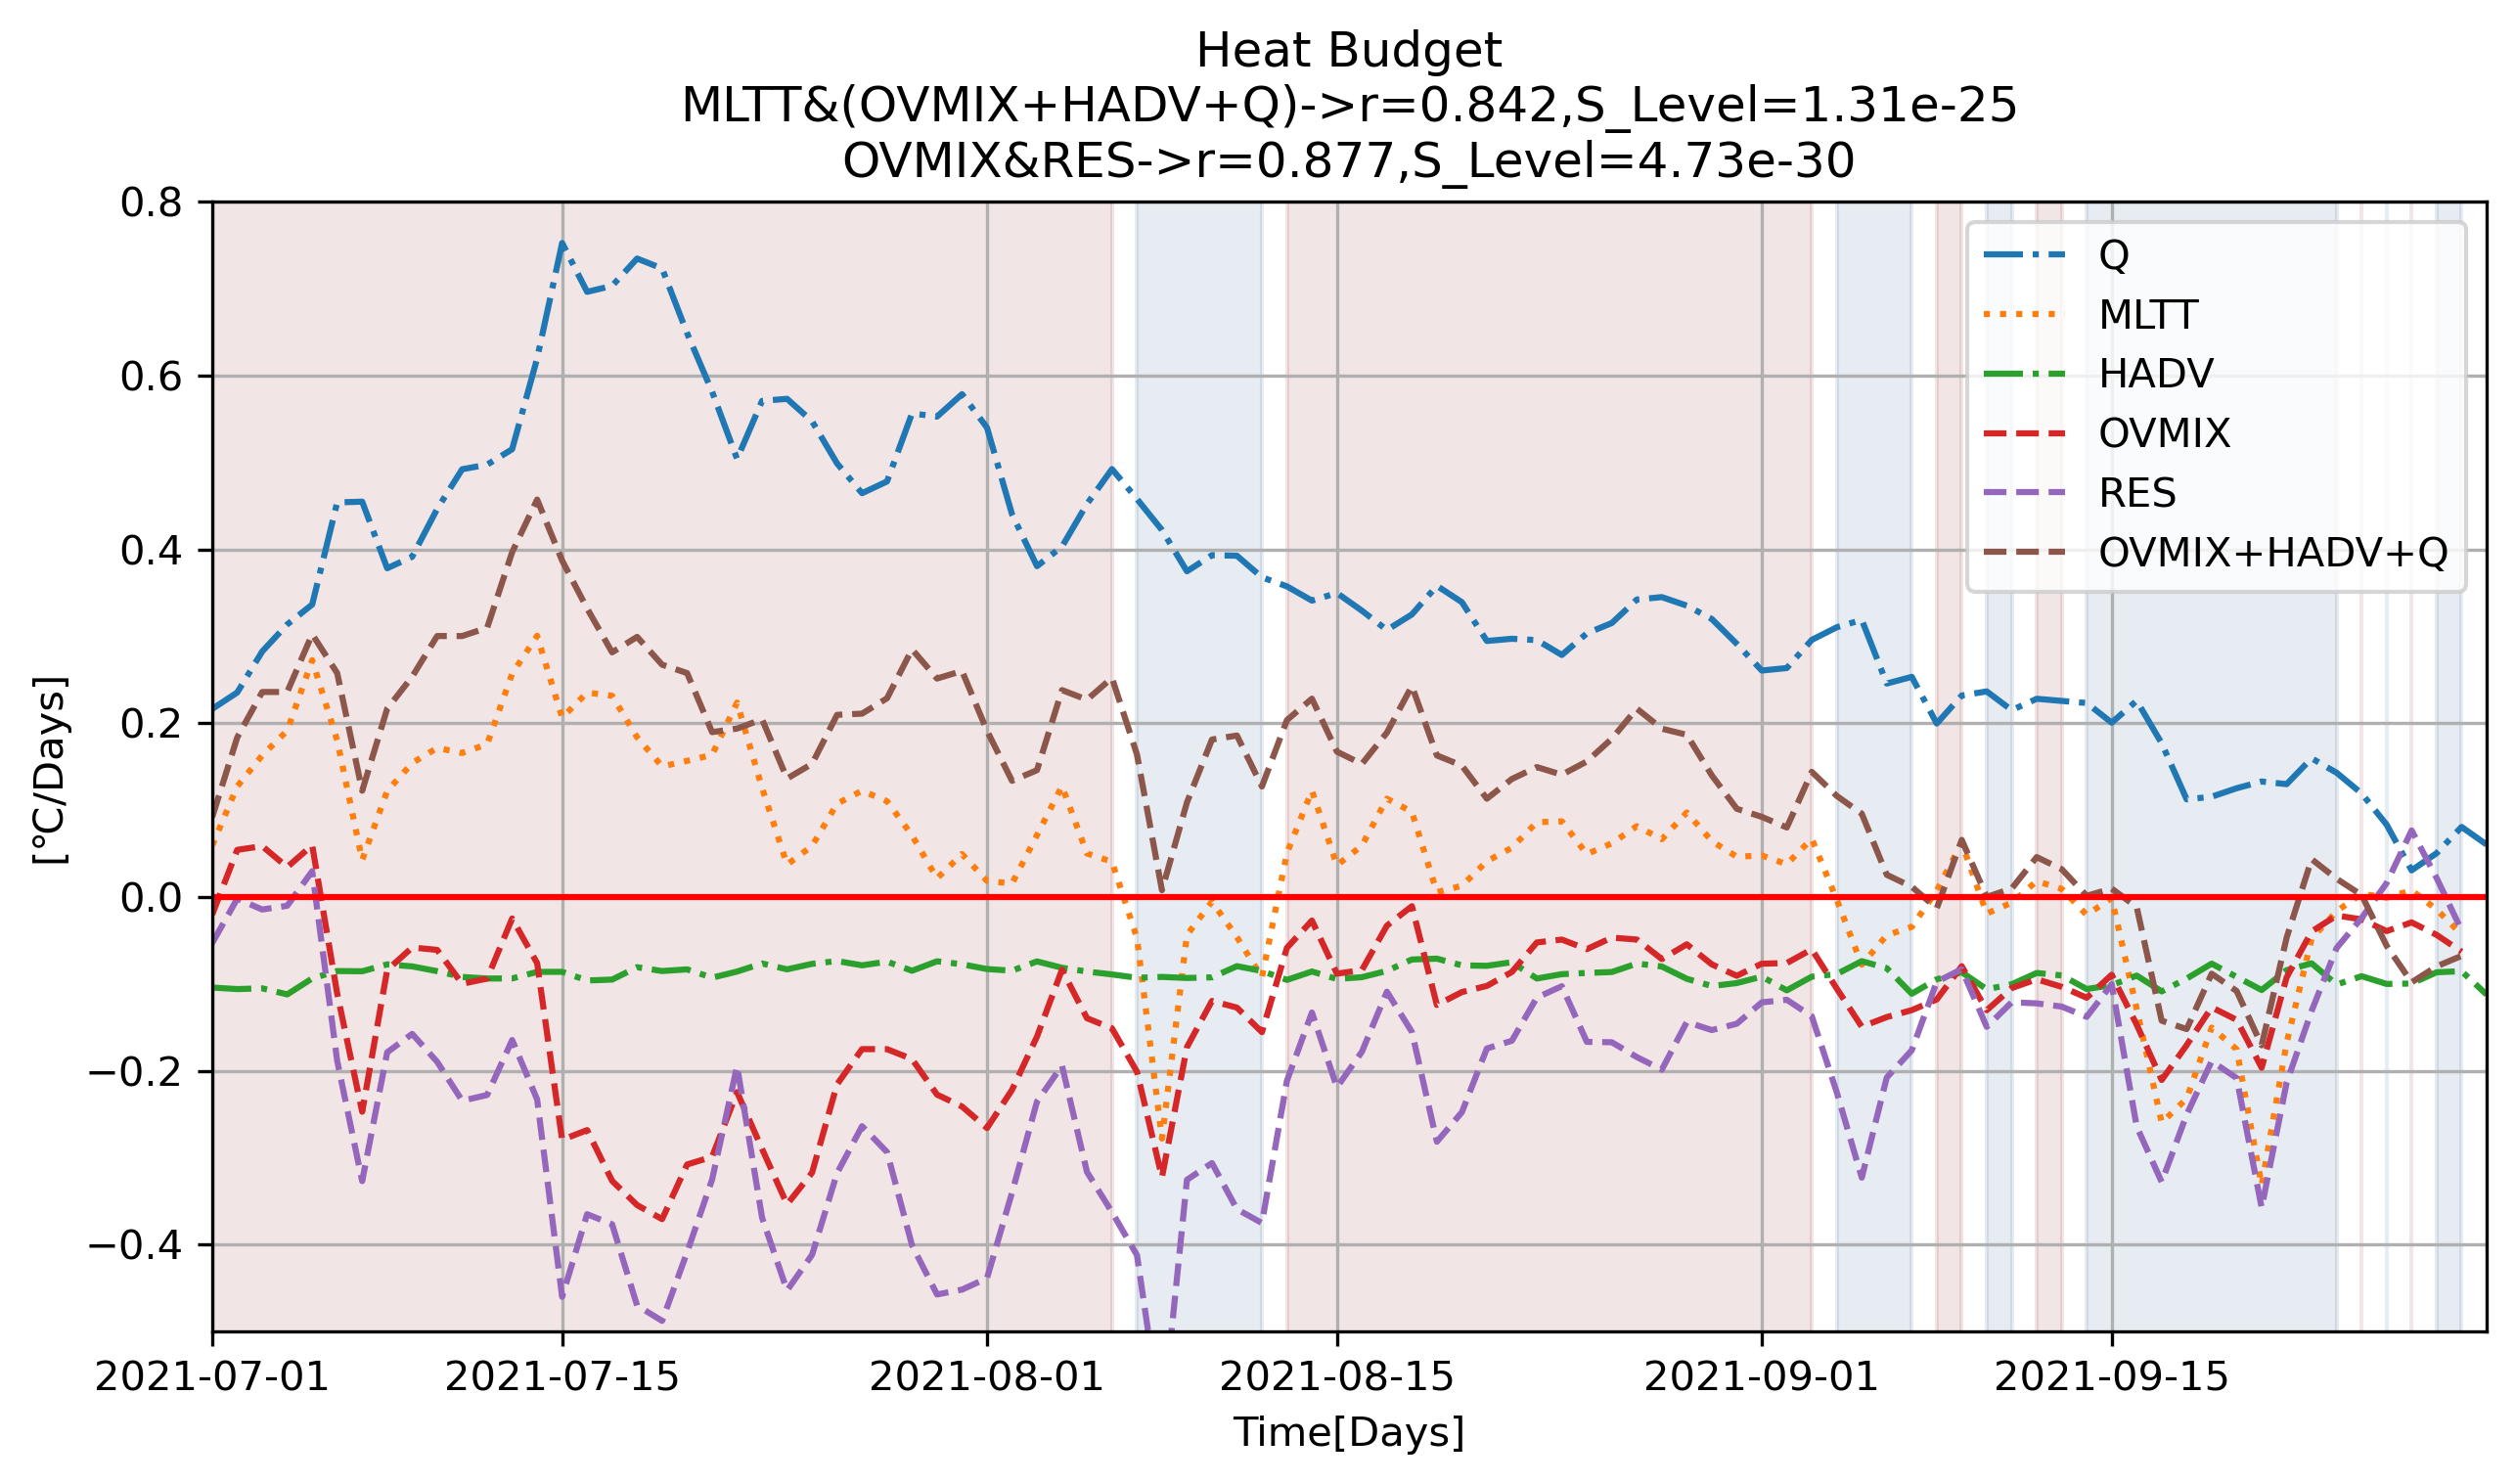

In [33]:



plt.figure(figsize=[10,5],dpi=300)
pc1 = pearsonr(np.mean(np.mean(Q,axis=1),axis=1)[:-1]+np.mean(np.mean(ovmix,axis=1),axis=1)+np.mean(np.mean(hadv,axis=1),axis=1)[:-1], np.mean(np.mean(mltt,axis=1),axis=1))
pc2 = pearsonr(np.mean(np.mean(ovmix,axis=1),axis=1), np.mean(np.mean(mltt,axis=1),axis=1)-np.mean(np.mean(Q,axis=1),axis=1)[:-1]-np.mean(np.mean(hadv,axis=1),axis=1)[:-1])
y0=np.zeros(shape=[time.shape[0]])
y1=np.copy(y0)
y1[:]=1000
y0[:]=-1000
plt.title('Heat Budget'+f'\nMLTT&(OVMIX+HADV+Q)->r={pc1[0]:.3f},S_Level={pc1[1]:.2e}'+f'\nOVMIX&RES->r={pc2[0]:.3f},S_Level={pc2[1]:.2e}')
plt.plot(time,np.mean(np.mean(Q,axis=1),axis=1),linestyle='-.',label='Q')
plt.plot(time[:-1],np.mean(np.mean(mltt,axis=1),axis=1),linestyle=':',label='MLTT')
plt.plot(time,np.mean(np.mean(hadv,axis=1),axis=1),linestyle='dashdot',label='HADV')
#pltsea of thieves Ocean.plot(time[:-1],np.mean(np.mean(ovmix1,axis=1),axis=1),label='ENT')
#plt.plot(time,np.mean(np.mean(ovmix2,axis=1),axis=1),label='MIX')
plt.plot(time[:-1],np.mean(np.mean(ovmix,axis=1),axis=1),linestyle='--',label='OVMIX')
plt.plot(time[:-1],np.mean(np.mean(mltt,axis=1),axis=1)-np.mean(np.mean(Q,axis=1),axis=1)[:-1]-np.mean(np.mean(hadv,axis=1),axis=1)[:-1],linestyle='--',label='RES')
plt.plot(time[:-1],np.mean(np.mean(Q,axis=1),axis=1)[:-1]+np.mean(np.mean(ovmix,axis=1),axis=1)+np.mean(np.mean(hadv,axis=1),axis=1)[:-1],linestyle='--',label='OVMIX+HADV+Q')
plt.legend()
plt.plot(time,np.array([0]*time.shape[0]),'r')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt,axis=1),axis=1)-0>0,alpha=0.1,color='#840000')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt,axis=1),axis=1)-0<0,alpha=0.1,color='#10457e')
plt.ylim(-0.5,0.8)
plt.xlim(time[0],time[-1])
plt.ylabel('[℃/Days]')
plt.xlabel('Time[Days]')
plt.grid()

In [34]:
pc = pearsonr(np.mean(np.mean(ovmix,axis=1),axis=1), np.mean(np.mean(mltt,axis=1),axis=1)-np.mean(np.mean(Q,axis=1),axis=1)[:-1]-np.mean(np.mean(hadv,axis=1),axis=1)[:-1])
print("OVMIX&RES相关系数：", pc[0])
print("OVMIX&RES显著性水平：", pc[1])

OVMIX&RES相关系数： 0.8768398287713945
OVMIX&RES显著性水平： 4.732819723881759e-30


In [35]:
from scipy.stats import pearsonr


pc = pearsonr(np.mean(np.mean(Q,axis=1),axis=1)[:-1][31:], np.mean(np.mean(mltt,axis=1),axis=1)[31:])
print("8_9 Q&MLTT相关系数：", pc[0])
print("8_9 Q&MLTT显著性水平：", pc[1])
pc = pearsonr(np.mean(np.mean(ovmix,axis=1),axis=1)[31:], np.mean(np.mean(mltt,axis=1),axis=1)[31:])
print("8_9 OVMIX&MLTT相关系数：", pc[0])
print("8_9 OVMIX&MLTT显著性水平：", pc[1])
pc = pearsonr(np.mean(np.mean(Q,axis=1),axis=1)[:-1][:31], np.mean(np.mean(mltt,axis=1),axis=1)[:31])
print("7 Q&MLTT相关系数：", pc[0])
print("7 Q&MLTT显著性水平：", pc[1])
pc = pearsonr(np.mean(np.mean(ovmix,axis=1),axis=1)[:31], np.mean(np.mean(mltt,axis=1),axis=1)[:31])
print("7 OVMIX&MLTT相关系数：", pc[0])
print("7 OVMIX&MLTT显著性水平：", pc[1])

8_9 Q&MLTT相关系数： 0.3688135177660119
8_9 Q&MLTT显著性水平： 0.0037351988812323483
8_9 OVMIX&MLTT相关系数： 0.6129058658552019
8_9 OVMIX&MLTT显著性水平： 1.9363638036555888e-07
7 Q&MLTT相关系数： 0.16943838761282526
7 Q&MLTT显著性水平： 0.36216990550671363
7 OVMIX&MLTT相关系数： 0.27114956581611194
7 OVMIX&MLTT显著性水平： 0.14008892650832472


In [36]:
pc = pearsonr(np.mean(np.mean(Q,axis=1),axis=1)[:-1][:31], np.mean(np.mean(mltt,axis=1),axis=1)[:31])
print("7 Q&MLTT相关系数：", pc[0])
print("7 Q&MLTT显著性水平：", pc[1])
pc = pearsonr(np.mean(np.mean(ovmix,axis=1),axis=1)[:31], np.mean(np.mean(mltt,axis=1),axis=1)[:31])
print("7 OVMIX&MLTT相关系数：", pc[0])
print("7 OVMIX&MLTT显著性水平：", pc[1])

7 Q&MLTT相关系数： 0.16943838761282526
7 Q&MLTT显著性水平： 0.36216990550671363
7 OVMIX&MLTT相关系数： 0.27114956581611194
7 OVMIX&MLTT显著性水平： 0.14008892650832472


In [37]:
import scipy.io as scio
scio.savemat('12_20_heatbudget.mat',{"Q":Q,"ovmix":ovmix,"hadv":hadv,"mltt":mltt,"time":time,"Q_net":Q_net,"Q_z":Q_z})
#np.savez('12_20_heatbudget.npz',Q=Q,ovmix=ovmix,hadv=hadv,mltt=mltt,time=time,Q_net=Q_net,Q_z=Q_z)